In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
pd.set_option('display.max_rows', None)

In [2]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
#val = pd.read_parquet('data/val.parquet')

In [3]:
x_cols = ['Cos_DayOfYear',
 'AvgPacketLen_Mean',
 'Min_PacketSpeed',
 'Min_DataSpeed',
 'Attack ID',
 'PacketSpeed_Per_Second',
 'DayOfYear',
 'PCA_3',
 'Max_DetectCount',
 'AvgPacketLen_Per_TotalSeconds',
 'AvgPacketLen_Std',
 'Mean_PacketSpeed',
 'dist_centroid_silhouette_72',
 'dist_centroid_silhouette_54',
 'Data speed',
 'Source IP count',
 'Avg source IP count',
 'Max_DataSpeed',
 'umap_2',
 'Is_SSH',
 'total_seconds',
 'Max_PacketSpeed',
 'PCA_2',
 'PCA_4',
 'Std_DataSpeed',
 'VictimIP_Count',
 'dist_centroid_silhouette_61',
 'Victim IP',
 'Start Hour',
 'Mean_DetectCount',
 'Mean_DataSpeed',
 'Std_DetectCount',
 'Sin_DayOfYear']

In [ ]:
x_cols = ['Attack ID', 'Avg source IP count', 'Detect count', 'Victim IP', 'Port number', 'Packet speed', 
          'Data speed', 'Avg packet len', 'Source IP count', 
          'Packet speed_normalized', 'Data speed_normalized', 'Avg packet len_normalized', 
          'total_seconds', 'weekday_number', 'time_of_day', 'IsWeekend', 'Start Hour', 'Sin_Hour', 
          'Cos_Hour', 'DayOfYear', 'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_PacketSpeed', 'Min_PacketSpeed', 
          'Max_PacketSpeed', 'Mean_DetectCount', 'Std_DetectCount', 'Min_DetectCount', 'Max_DetectCount', 
          'VictimIP_Count', 'PortNumber_Count', 'AvgPacketLen_Mean', 'AvgPacketLen_Std', 
          'DataSpeed_PacketSpeed', 'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second',
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 'Is_DNS', 'Is_POP3',
          'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 
          'Is_TFTP', 'Is_MySQL', 'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081',
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 'Is_NTP', 'Is_Kerberos', 
          'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 
          'Is_BGP', 'Is_IMAPS_Alt', 'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 'Is_Modbus', 'Is_CoAP', 
          'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 'Is_Elasticsearch', 'Is_Zookeeper', 
          'Is_Cassandra', 'Is_Docker', 'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 
          'Is_DHCPv6', 'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH',
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'cluster', 'cluster112', 'dist_centroid_0',
          'dist_centroid_1', 'dist_centroid_2', 'dist_centroid_3', 'dist_centroid_4',
          'dist_centroid_5', 'dist_centroid_6', 'dist_centroid_7', 'dist_centroid_8',
          'dist_centroid_9', 'dist_centroid_10', 'dist_centroid_11', 'dist_centroid_12',
          'dist_centroid_13', 'dist_centroid_14', 'dist_centroid_15', 'dist_centroid_16','dist_centroid_17',
          'dist_centroid_silhouette_1', 'dist_centroid_silhouette_2', 'dist_centroid_silhouette_3',
          'dist_centroid_silhouette_4', 'dist_centroid_silhouette_5', 'dist_centroid_silhouette_6',
          'dist_centroid_silhouette_7','dist_centroid_silhouette_8','dist_centroid_silhouette_9',
          'dist_centroid_silhouette_10','dist_centroid_silhouette_11','dist_centroid_silhouette_12',
          'dist_centroid_silhouette_13','dist_centroid_silhouette_14','dist_centroid_silhouette_15',
          'dist_centroid_silhouette_16','dist_centroid_silhouette_17','dist_centroid_silhouette_18',
          'dist_centroid_silhouette_19','dist_centroid_silhouette_20','dist_centroid_silhouette_21',
          'dist_centroid_silhouette_22','dist_centroid_silhouette_23','dist_centroid_silhouette_24',
          'dist_centroid_silhouette_25','dist_centroid_silhouette_26','dist_centroid_silhouette_27',
          'dist_centroid_silhouette_28','dist_centroid_silhouette_29','dist_centroid_silhouette_30',
          'dist_centroid_silhouette_31','dist_centroid_silhouette_32','dist_centroid_silhouette_33',
          'dist_centroid_silhouette_34','dist_centroid_silhouette_35','dist_centroid_silhouette_36',
          'dist_centroid_silhouette_37','dist_centroid_silhouette_38','dist_centroid_silhouette_39',
          'dist_centroid_silhouette_40','dist_centroid_silhouette_41','dist_centroid_silhouette_42',
          'dist_centroid_silhouette_43','dist_centroid_silhouette_44','dist_centroid_silhouette_45',
          'dist_centroid_silhouette_46','dist_centroid_silhouette_47','dist_centroid_silhouette_48',
          'dist_centroid_silhouette_49','dist_centroid_silhouette_50','dist_centroid_silhouette_51',
          'dist_centroid_silhouette_52','dist_centroid_silhouette_53','dist_centroid_silhouette_54',
 'dist_centroid_silhouette_55',
 'dist_centroid_silhouette_56',
 'dist_centroid_silhouette_57',
 'dist_centroid_silhouette_58',
 'dist_centroid_silhouette_59',
 'dist_centroid_silhouette_60',
 'dist_centroid_silhouette_61',
 'dist_centroid_silhouette_62',
 'dist_centroid_silhouette_63',
 'dist_centroid_silhouette_64',
 'dist_centroid_silhouette_65',
 'dist_centroid_silhouette_66',
 'dist_centroid_silhouette_67',
 'dist_centroid_silhouette_68',
 'dist_centroid_silhouette_69',
 'dist_centroid_silhouette_70',
 'dist_centroid_silhouette_71',
 'dist_centroid_silhouette_72',
 'dist_centroid_silhouette_73',
 'dist_centroid_silhouette_74',
 'dist_centroid_silhouette_75',
 'dist_centroid_silhouette_76',
 'dist_centroid_silhouette_77',
 'dist_centroid_silhouette_78',
 'dist_centroid_silhouette_79',
 'dist_centroid_silhouette_80',
 'dist_centroid_silhouette_81',
 'dist_centroid_silhouette_82',
 'dist_centroid_silhouette_83',
 'dist_centroid_silhouette_84',
 'dist_centroid_silhouette_85',
 'dist_centroid_silhouette_86',
 'dist_centroid_silhouette_87',
 'dist_centroid_silhouette_88',
 'dist_centroid_silhouette_89',
 'dist_centroid_silhouette_90',
 'dist_centroid_silhouette_91',
 'dist_centroid_silhouette_92',
 'dist_centroid_silhouette_93',
 'dist_centroid_silhouette_94',
 'dist_centroid_silhouette_95',
 'dist_centroid_silhouette_96',
 'dist_centroid_silhouette_97',
 'dist_centroid_silhouette_98',
 'dist_centroid_silhouette_99',
 'dist_centroid_silhouette_100',
 'dist_centroid_silhouette_101',
 'dist_centroid_silhouette_102',
 'dist_centroid_silhouette_103',
 'dist_centroid_silhouette_104',
 'dist_centroid_silhouette_105',
 'dist_centroid_silhouette_106',
 'dist_centroid_silhouette_107',
 'dist_centroid_silhouette_108',
 'dist_centroid_silhouette_109',
 'dist_centroid_silhouette_110',
 'dist_centroid_silhouette_111', 
 'tsne_1','tsne_0', 'umap_1', 'umap_2']

# Soft voting


In [ ]:
# Assuming you have your data loaded into 'train' and 'test' DataFrames
# and 'x_cols' is a list of feature column names.

# Separate features (X) and target (y) for training and testing
from xgboost import XGBClassifier


X_train = train[x_cols]
y_train = train['Type']
X_test = test[x_cols]
y_test = test['Type']

# {'n_estimators': 65, 'max_depth': 45, 'min_samples_split': 8, 'min_samples_leaf': 4}
# {'n_estimators': 415, 'learning_rate': 0.05510555889486818, 'num_leaves': 62, 'max_depth': 7, 'min_child_samples': 35, 'subsample': 0.9290522441294119, 'colsample_bytree': 0.7486543996305447}
#{'booster': 'gbtree', 'alpha': 0.43956717471385465, 'subsample': 0.5248001386035008, 'colsample_bytree': 0.8647362305652437, 'max_depth': 4, 'eta': 0.17688927631326914, 'gamma': 0.7809600844789752, 'grow_policy': 'lossguide', 'min_child_weight': 7}

rf_clf = RandomForestClassifier(n_estimators=65, max_depth=45, min_samples_split=8, min_samples_leaf=4, random_state=42, class_weight='balanced')
lgbm_clf = lgb.LGBMClassifier(verbose=-1, n_estimators=415, learning_rate=0.05510555889486818, num_leaves=62, max_depth=7, 
                          min_child_samples=35, subsample=0.9290522441294119, colsample_bytree=0.7486543996305447, random_state=42, is_unbalance=True)
xgb_clf = xgbm = xgb.XGBClassifier(
    objective='multi:softmax',
        num_class=3,
        booster=('gbtree'),
        alpha=0.43956717471385465,
        subsample=0.5248001386035008,
        colsample_bytree=0.8647362305652437,
        max_depth=4,
        eta=0.17688927631326914,
        gamma=0.7809600844789752,
        grow_policy='lossguide',
        min_child_weight=6,
        eval_metric='merror',  # Multi-class error for evaluation
        random_state=42
        )# Create the voting classifier (soft voting requires probability estimates)
voting_clf_soft = VotingClassifier(
    estimators=[('rf', rf_clf), ('lgbm', lgbm_clf), ('xgb', xgb_clf)],
    voting='soft'
)

In [6]:
from sklearn.base import is_classifier
print(is_classifier(xgb_clf)) # This should return True

True


In [7]:
# Train the voting classifier
voting_clf_soft.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('lgbm', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",390
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",24
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1



Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.66      0.63    305167
           1       0.88      0.87      0.88    919196
           2       0.95      0.24      0.38     22903

    accuracy                           0.81   1247266
   macro avg       0.81      0.59      0.63   1247266
weighted avg       0.81      0.81      0.81   1247266



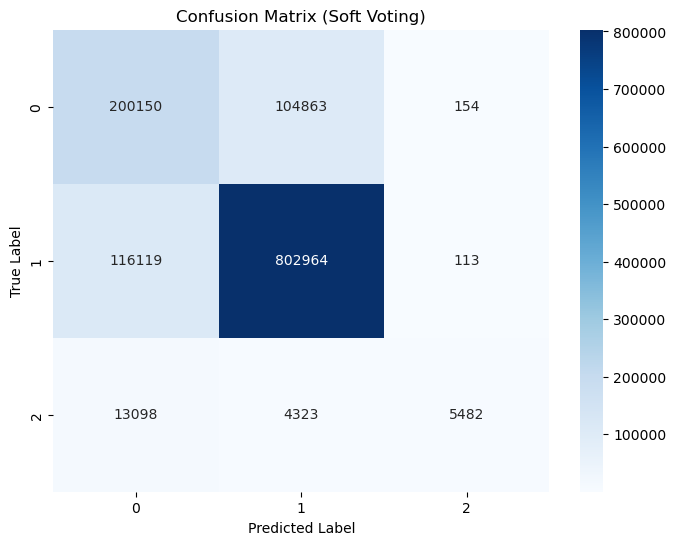


Confusion Matrix:
[[200150 104863    154]
 [116119 802964    113]
 [ 13098   4323   5482]]


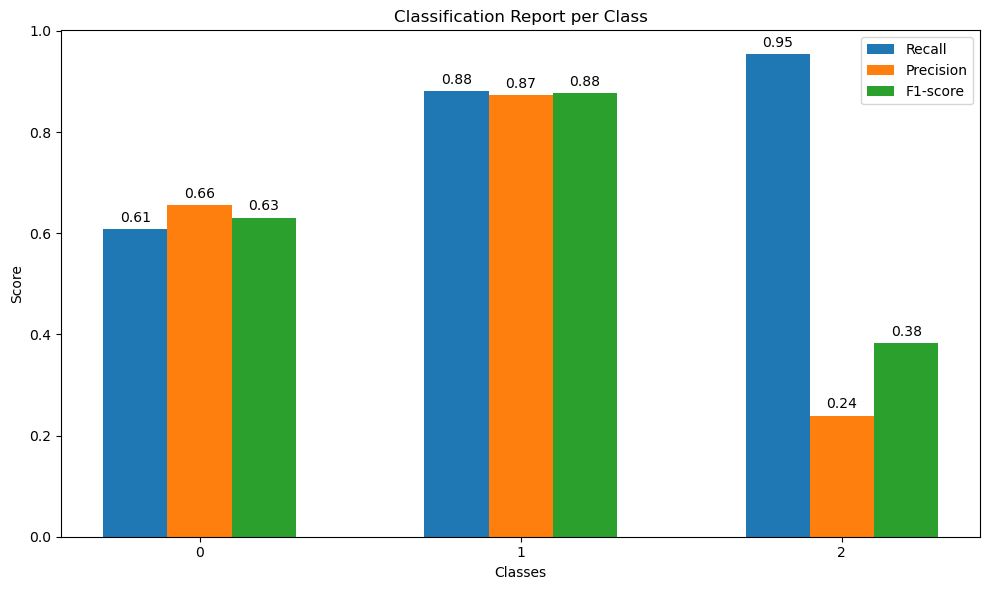

Accuracy: 0.8086454693706074
Precision: 0.8138453769019317
Recall: 0.589592681764562


In [8]:

# Make predictions on the test set
test['pred_soft'] = voting_clf_soft.predict(test[x_cols])


# Generate the classification report
report_soft = classification_report(test['Type'], test['pred_soft'])
print("\nClassification Report:")
print(report_soft)

# Generate the confusion matrix
cm_soft = confusion_matrix(test['Type'], test['pred_soft'])

# Visualize the confusion matrix
class_labels_soft = np.unique(test['Type'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_soft, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_soft, yticklabels=class_labels_soft)
plt.xlabel('Predicted Label')   
plt.ylabel('True Label')
plt.title('Confusion Matrix (Soft Voting)')
plt.show()

# Print the confusion matrix (textual representation)
print("\nConfusion Matrix:")
print(cm_soft)

report = classification_report(test['Type'], test['pred_soft'], output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()

accuracy = accuracy_score(test['Type'], test['pred_soft'])
print("Accuracy:", accuracy)
precision = precision_score(test['Type'], test['pred_soft'], average='macro')
print("Precision:", precision)
recall = recall_score(test['Type'], test['pred_soft'], average='macro')
print("Recall:", recall)
##f1 = f1_score(test['Type'], test['pred_soft'], average='macro')
##print("F1-Score:", f1)

# Hard voting


In [9]:
# Optional: Evaluate Hard Voting Classifier as well
voting_clf_hard = VotingClassifier(
    estimators=[('rf', rf_clf), ('lgbm', lgbm_clf), ('xgb', xgb_clf)],
    voting='hard',
    flatten_transform=True 
)

voting_clf_hard.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('lgbm', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",390
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",24
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [10]:
pred_hard = voting_clf_hard.predict(test[x_cols])


Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.68      0.64    305167
           1       0.89      0.87      0.88    919196
           2       0.97      0.20      0.33     22903

    accuracy                           0.81   1247266
   macro avg       0.82      0.58      0.62   1247266
weighted avg       0.82      0.81      0.81   1247266



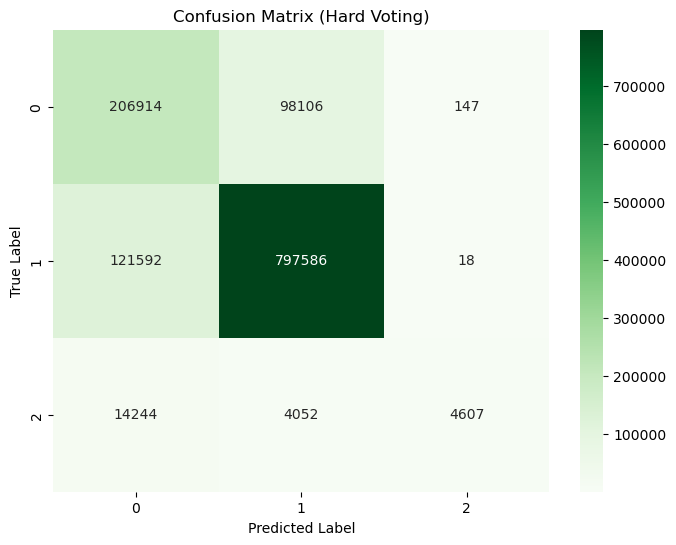


Confusion Matrix:
[[206914  98106    147]
 [121592 797586     18]
 [ 14244   4052   4607]]


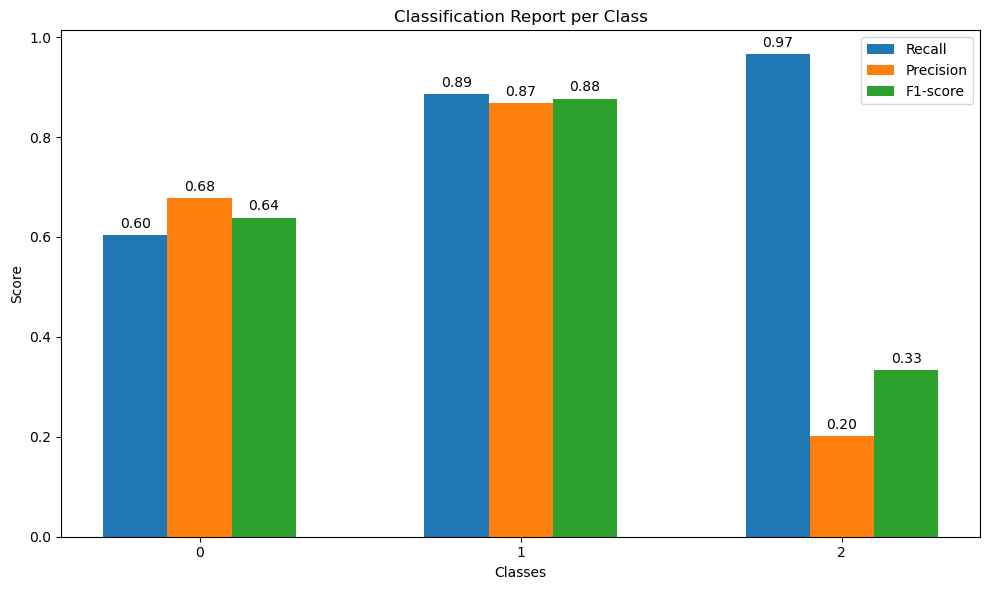

In [11]:
report_hard = classification_report(test['Type'], pred_hard)
print("\nClassification Report:")
print(report_hard)

cm_hard = confusion_matrix(test['Type'], pred_hard)
class_labels_hard = np.unique(test['Type'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hard, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels_hard, yticklabels=class_labels_hard)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Hard Voting)')
plt.show()

print("\nConfusion Matrix:")
print(cm_hard)

report = classification_report(test['Type'], pred_hard, output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()

# Testing dimension size


In [8]:
def evaluate(x_cols):
    X_train = train[x_cols]
    y_train = train['Type']
    X_test = test[x_cols]
    y_test = test['Type']

    # Initialize the individual classifiers
    rf_clf = RandomForestClassifier(n_estimators=437, random_state=42, max_depth=37, min_samples_split=10, min_samples_leaf=5, verbose=0)
    lgbm_clf = lgb.LGBMClassifier(verbose=-1, n_estimators=351, learning_rate=0.05719243532859288, num_leaves=47, max_depth=5, min_child_samples=42, subsample=0.8896113748808988, colsample_bytree=0.9577482057904019, random_state=42)
    xgb_clf = xgb.XGBClassifier(objective='multi:softmax', num_class=3,booster=('gbtree'),alpha=0.8929914624140356,subsample=0.5245590585473099,colsample_bytree=0.41745486572446977,max_depth=10,eta=0.03343544751435021,gamma=0.36103800824329335,grow_policy='lossguide',min_child_weight=2,eval_metric='merror',  random_state=42)

    # Create the voting classifier (soft voting requires probability estimates)
    voting_clf_soft = VotingClassifier(
        estimators=[('rf', rf_clf), ('lgbm', lgbm_clf), ('xgb', xgb_clf)],
        voting='soft'
    )
    voting_clf_soft.fit(X_train, y_train)



    test['pred_soft'] = voting_clf_soft.predict(test[x_cols])


    # Generate the classification report
    report_soft = classification_report(test['Type'], test['pred_soft'])
    print("\nClassification Report:")
    print(report_soft)

    # Generate the confusion matrix
    cm_soft = confusion_matrix(test['Type'], test['pred_soft'])

    # Visualize the confusion matrix
    class_labels_soft = np.unique(test['Type'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_soft, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels_soft, yticklabels=class_labels_soft)
    plt.xlabel('Predicted Label')   
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Soft Voting)')
    plt.show()

    # Print the confusion matrix (textual representation)
    print("\nConfusion Matrix:")
    print(cm_soft)

    report = classification_report(test['Type'], test['pred_soft'], output_dict=True)

    # 2. Extract the data for plotting
    classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
    precision = [report[cls]['precision'] for cls in classes]
    recall = [report[cls]['recall'] for cls in classes]
    f1_score = [report[cls]['f1-score'] for cls in classes]

    # 3. Set up the plot
    x = np.arange(len(classes))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width, precision, width, label='Recall')
    rects2 = ax.bar(x, recall, width, label='Precision')
    rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Score')
    ax.set_xlabel('Classes')
    ax.set_title('Classification Report per Class')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()

    ax.bar_label(rects1, fmt='%.2f', padding=3)
    ax.bar_label(rects2, fmt='%.2f', padding=3)
    ax.bar_label(rects3, fmt='%.2f', padding=3)

    fig.tight_layout()
    plt.show()

    accuracy = accuracy_score(test['Type'], test['pred_soft'])
    print("Accuracy:", accuracy)
    precision = precision_score(test['Type'], test['pred_soft'], average='macro')
    print("Precision:", precision)
    recall = recall_score(test['Type'], test['pred_soft'], average='macro')
    print("Recall:", recall)

full x_cols


In [7]:
x_cols = ['Attack ID', 'Avg source IP count', 'Detect count', 'Victim IP', 'Port number', 'Packet speed', 
          'Data speed', 'Avg packet len', 'Source IP count', 
          'Packet speed_normalized', 'Data speed_normalized', 'Avg packet len_normalized', 
          'total_seconds', 'weekday_number', 'time_of_day', 'IsWeekend', 'Start Hour', 'Sin_Hour', 
          'Cos_Hour', 'DayOfYear', 'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_PacketSpeed', 'Min_PacketSpeed', 
          'Max_PacketSpeed', 'Mean_DetectCount', 'Std_DetectCount', 'Min_DetectCount', 'Max_DetectCount', 
          'VictimIP_Count', 'PortNumber_Count', 'AvgPacketLen_Mean', 'AvgPacketLen_Std', 
          'DataSpeed_PacketSpeed', 'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second',
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 'Is_DNS', 'Is_POP3',
          'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 
          'Is_TFTP', 'Is_MySQL', 'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081',
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 'Is_NTP', 'Is_Kerberos', 
          'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 
          'Is_BGP', 'Is_IMAPS_Alt', 'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 'Is_Modbus', 'Is_CoAP', 
          'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 'Is_Elasticsearch', 'Is_Zookeeper', 
          'Is_Cassandra', 'Is_Docker', 'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 
          'Is_DHCPv6', 'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH',
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'cluster', 'cluster112', 'dist_centroid_0',
          'dist_centroid_1', 'dist_centroid_2', 'dist_centroid_3', 'dist_centroid_4',
          'dist_centroid_5', 'dist_centroid_6', 'dist_centroid_7', 'dist_centroid_8',
          'dist_centroid_9', 'dist_centroid_10', 'dist_centroid_11', 'dist_centroid_12',
          'dist_centroid_13', 'dist_centroid_14', 'dist_centroid_15', 'dist_centroid_16','dist_centroid_17',
          'dist_centroid_silhouette_1', 'dist_centroid_silhouette_2', 'dist_centroid_silhouette_3',
          'dist_centroid_silhouette_4', 'dist_centroid_silhouette_5', 'dist_centroid_silhouette_6',
          'dist_centroid_silhouette_7','dist_centroid_silhouette_8','dist_centroid_silhouette_9',
          'dist_centroid_silhouette_10','dist_centroid_silhouette_11','dist_centroid_silhouette_12',
          'dist_centroid_silhouette_13','dist_centroid_silhouette_14','dist_centroid_silhouette_15',
          'dist_centroid_silhouette_16','dist_centroid_silhouette_17','dist_centroid_silhouette_18',
          'dist_centroid_silhouette_19','dist_centroid_silhouette_20','dist_centroid_silhouette_21',
          'dist_centroid_silhouette_22','dist_centroid_silhouette_23','dist_centroid_silhouette_24',
          'dist_centroid_silhouette_25','dist_centroid_silhouette_26','dist_centroid_silhouette_27',
          'dist_centroid_silhouette_28','dist_centroid_silhouette_29','dist_centroid_silhouette_30',
          'dist_centroid_silhouette_31','dist_centroid_silhouette_32','dist_centroid_silhouette_33',
          'dist_centroid_silhouette_34','dist_centroid_silhouette_35','dist_centroid_silhouette_36',
          'dist_centroid_silhouette_37','dist_centroid_silhouette_38','dist_centroid_silhouette_39',
          'dist_centroid_silhouette_40','dist_centroid_silhouette_41','dist_centroid_silhouette_42',
          'dist_centroid_silhouette_43','dist_centroid_silhouette_44','dist_centroid_silhouette_45',
          'dist_centroid_silhouette_46','dist_centroid_silhouette_47','dist_centroid_silhouette_48',
          'dist_centroid_silhouette_49','dist_centroid_silhouette_50','dist_centroid_silhouette_51',
          'dist_centroid_silhouette_52','dist_centroid_silhouette_53','dist_centroid_silhouette_54',
 'dist_centroid_silhouette_55',
 'dist_centroid_silhouette_56',
 'dist_centroid_silhouette_57',
 'dist_centroid_silhouette_58',
 'dist_centroid_silhouette_59',
 'dist_centroid_silhouette_60',
 'dist_centroid_silhouette_61',
 'dist_centroid_silhouette_62',
 'dist_centroid_silhouette_63',
 'dist_centroid_silhouette_64',
 'dist_centroid_silhouette_65',
 'dist_centroid_silhouette_66',
 'dist_centroid_silhouette_67',
 'dist_centroid_silhouette_68',
 'dist_centroid_silhouette_69',
 'dist_centroid_silhouette_70',
 'dist_centroid_silhouette_71',
 'dist_centroid_silhouette_72',
 'dist_centroid_silhouette_73',
 'dist_centroid_silhouette_74',
 'dist_centroid_silhouette_75',
 'dist_centroid_silhouette_76',
 'dist_centroid_silhouette_77',
 'dist_centroid_silhouette_78',
 'dist_centroid_silhouette_79',
 'dist_centroid_silhouette_80',
 'dist_centroid_silhouette_81',
 'dist_centroid_silhouette_82',
 'dist_centroid_silhouette_83',
 'dist_centroid_silhouette_84',
 'dist_centroid_silhouette_85',
 'dist_centroid_silhouette_86',
 'dist_centroid_silhouette_87',
 'dist_centroid_silhouette_88',
 'dist_centroid_silhouette_89',
 'dist_centroid_silhouette_90',
 'dist_centroid_silhouette_91',
 'dist_centroid_silhouette_92',
 'dist_centroid_silhouette_93',
 'dist_centroid_silhouette_94',
 'dist_centroid_silhouette_95',
 'dist_centroid_silhouette_96',
 'dist_centroid_silhouette_97',
 'dist_centroid_silhouette_98',
 'dist_centroid_silhouette_99',
 'dist_centroid_silhouette_100',
 'dist_centroid_silhouette_101',
 'dist_centroid_silhouette_102',
 'dist_centroid_silhouette_103',
 'dist_centroid_silhouette_104',
 'dist_centroid_silhouette_105',
 'dist_centroid_silhouette_106',
 'dist_centroid_silhouette_107',
 'dist_centroid_silhouette_108',
 'dist_centroid_silhouette_109',
 'dist_centroid_silhouette_110',
 'dist_centroid_silhouette_111', 'dbscan_cluster', 'tsne_1','tsne_2', 'umap_1', 'umap_2']


Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.37      0.47    305167
           1       0.80      0.93      0.86    919196
           2       0.96      0.20      0.33     22903

    accuracy                           0.78   1247266
   macro avg       0.80      0.50      0.55   1247266
weighted avg       0.76      0.78      0.76   1247266



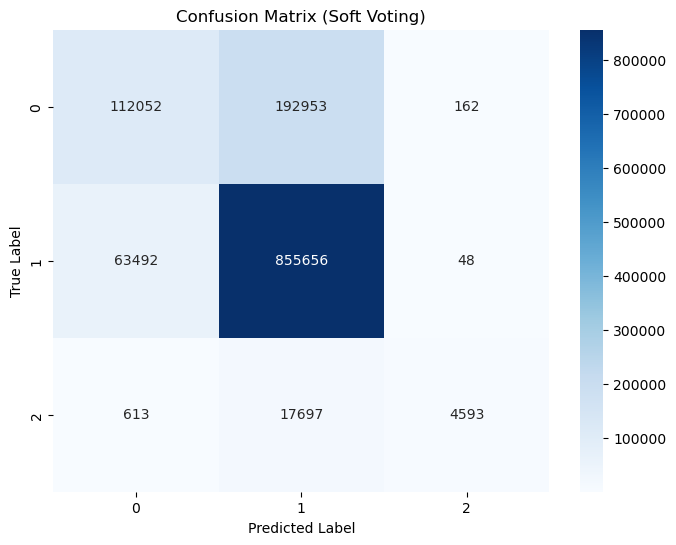


Confusion Matrix:
[[112052 192953    162]
 [ 63492 855656     48]
 [   613  17697   4593]]


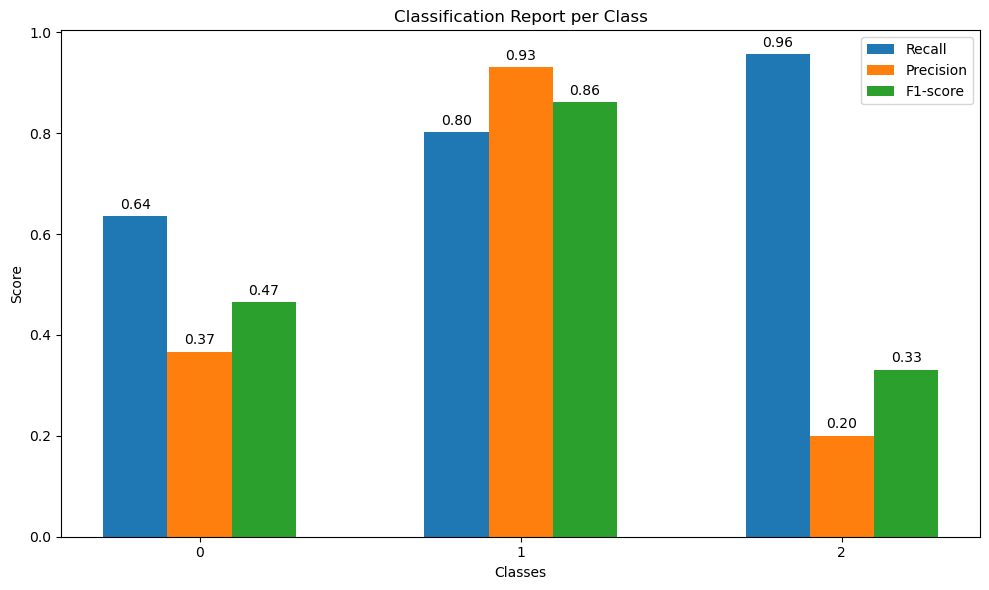

Accuracy: 0.7795458226232416
Precision: 0.7982726076361919
Recall: 0.49953278188929323


In [8]:
evaluate(x_cols)

Top 100


In [9]:
x_cols = ['Min_PacketSpeed',
 'Mean_DetectCount',
 'Std_DetectCount',
 'Max_DetectCount',
 'Std_DataSpeed',
 'Avg source IP count',
 'Mean_DataSpeed',
 'total_seconds',
 'Attack ID',
 'Max_PacketSpeed',
 'Mean_PacketSpeed',
 'DayOfYear',
 'AvgPacketLen_Mean',
 'PCA_4',
 'Sin_DayOfYear',
 'AvgPacketLen_Std',
 'Cos_DayOfYear',
 'Source IP count',
 'AvgPacketLen_Per_TotalSeconds',
 'PCA_3',
 'Min_DataSpeed',
 'PCA_5',
 'PCA_2',
 'Max_DataSpeed',
 'Start Hour',
 'VictimIP_Count',
 'Cos_Hour',
 'Victim IP',
 'Sin_Hour',
 'weekday_number',
 'time_of_day',
 'dist_centroid_silhouette_39',
 'Port number',
 'Detect count',
 'dist_centroid_silhouette_61',
 'PortNumber_Count',
 'DataSpeed_Per_TotalSeconds',
 'dist_centroid_silhouette_54',
 'dist_centroid_silhouette_31',
 'Data speed_normalized',
 'PacketSpeed_Per_Second',
 'dist_centroid_silhouette_62',
 'Avg packet len_normalized',
 'Avg packet len',
 'PortFrequency',
 'Packet speed',
 'packet_Total',
 'dist_centroid_silhouette_15',
 'tsne_2',
 'dist_centroid_17',
 'dist_centroid_silhouette_98',
 'Data speed',
 'Packet speed_normalized',
 'dist_centroid_silhouette_72',
 'dist_centroid_0',
 'dist_centroid_silhouette_63',
 'dist_centroid_silhouette_111',
 'IsWeekend',
 'umap_1',
 'dist_centroid_silhouette_8',
 'dist_centroid_12',
 'tsne_1',
 'dist_centroid_silhouette_104',
 'dist_centroid_silhouette_58',
 'dist_centroid_silhouette_87',
 'dist_centroid_silhouette_19',
 'dist_centroid_silhouette_36',
 'dist_centroid_silhouette_85',
 'dist_centroid_silhouette_57',
 'dist_centroid_silhouette_45',
 'dist_centroid_silhouette_20',
 'dist_centroid_2',
 'dist_centroid_silhouette_35',
 'Is_SSH',
 'Std_DetectCount_Replaced',
 'dist_centroid_silhouette_96',
 'umap_2',
 'dist_centroid_silhouette_51',
 'dist_centroid_silhouette_64',
 'PCA_1',
 'dist_centroid_silhouette_88',
 'dist_centroid_silhouette_3',
 'dist_centroid_6',
 'AvgPacketLen_Std_Replaced',
 'dist_centroid_silhouette_99',
 'dist_centroid_silhouette_43',
 'dist_centroid_silhouette_109',
 'dist_centroid_silhouette_89',
 'dist_centroid_silhouette_12',
 'dist_centroid_silhouette_90',
 'dist_centroid_silhouette_102',
 'dist_centroid_8',
 'dist_centroid_silhouette_55',
 'dist_centroid_silhouette_42',
 'dist_centroid_1',
 'dist_centroid_silhouette_75',
 'Std_DataSpeed_Replaced',
 'dist_centroid_silhouette_94',
 'dist_centroid_14',
 'dist_centroid_silhouette_56']


Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.36      0.47    305167
           1       0.80      0.94      0.87    919196
           2       0.96      0.20      0.32     22903

    accuracy                           0.78   1247266
   macro avg       0.81      0.50      0.55   1247266
weighted avg       0.77      0.78      0.76   1247266



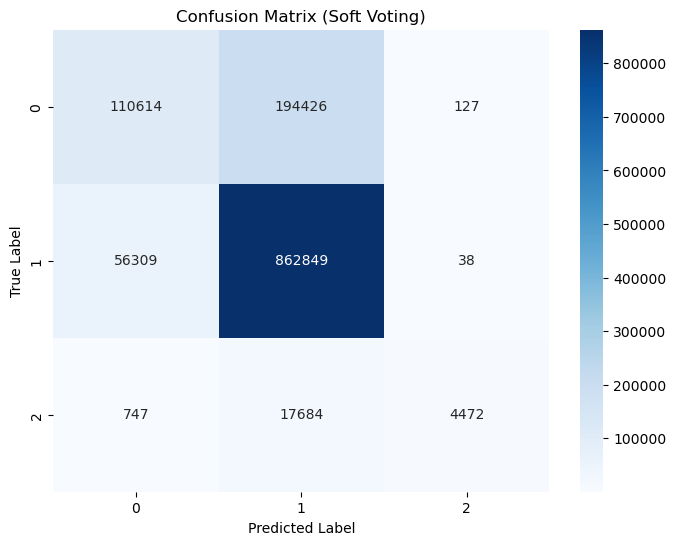


Confusion Matrix:
[[110614 194426    127]
 [ 56309 862849     38]
 [   747  17684   4472]]


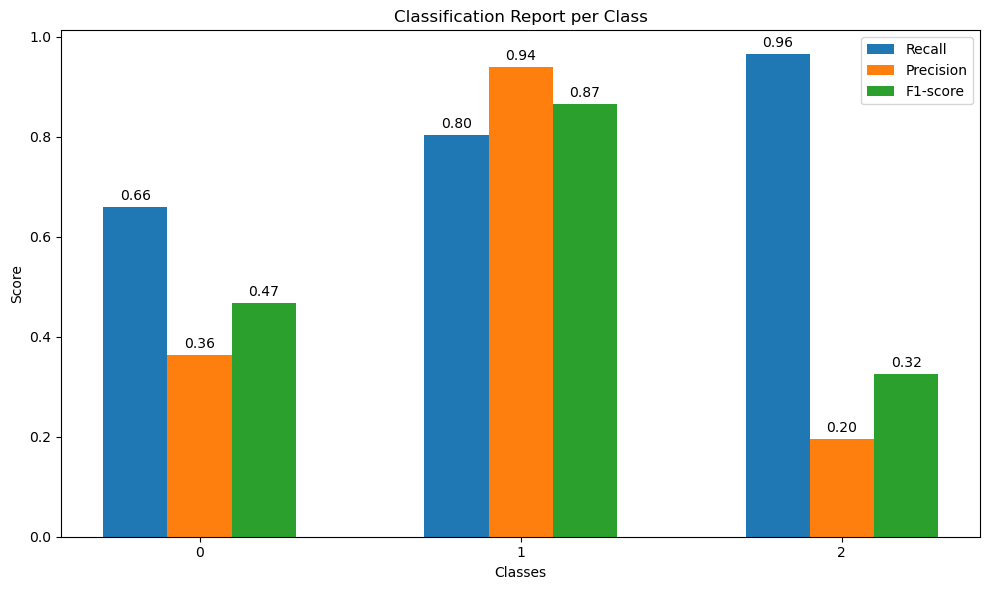

Accuracy: 0.7840629023800857
Precision: 0.8089366752311841
Recall: 0.49880944596877813


In [10]:
evaluate(x_cols)

Top 75


In [11]:
x_cols = ['Min_PacketSpeed',
 'Max_DetectCount',
 'Std_DetectCount',
 'Mean_DetectCount',
 'Avg source IP count',
 'Std_DataSpeed',
 'Attack ID',
 'Max_PacketSpeed',
 'total_seconds',
 'Mean_DataSpeed',
 'AvgPacketLen_Mean',
 'AvgPacketLen_Std',
 'Mean_PacketSpeed',
 'Source IP count',
 'DayOfYear',
 'Cos_DayOfYear',
 'Sin_DayOfYear',
 'PCA_4',
 'AvgPacketLen_Per_TotalSeconds',
 'PCA_3',
 'Min_DataSpeed',
 'Start Hour',
 'PCA_2',
 'PCA_5',
 'Max_DataSpeed',
 'VictimIP_Count',
 'Sin_Hour',
 'dist_centroid_silhouette_54',
 'Victim IP',
 'Cos_Hour',
 'dist_centroid_silhouette_72',
 'weekday_number',
 'dist_centroid_silhouette_39',
 'time_of_day',
 'Detect count',
 'dist_centroid_silhouette_98',
 'Port number',
 'dist_centroid_silhouette_61',
 'PortNumber_Count',
 'DataSpeed_Per_TotalSeconds',
 'Avg packet len',
 'Avg packet len_normalized',
 'dist_centroid_silhouette_15',
 'dist_centroid_silhouette_62',
 'PortFrequency',
 'dist_centroid_17',
 'dist_centroid_silhouette_31',
 'Packet speed',
 'PacketSpeed_Per_Second',
 'Data speed_normalized',
 'Data speed',
 'IsWeekend',
 'dist_centroid_silhouette_111',
 'Packet speed_normalized',
 'umap_1',
 'packet_Total',
 'dist_centroid_0',
 'dist_centroid_silhouette_87',
 'dist_centroid_silhouette_63',
 'tsne_2',
 'tsne_1',
 'dist_centroid_8',
 'dist_centroid_silhouette_19',
 'Is_SSH',
 'dist_centroid_12',
 'dist_centroid_silhouette_85',
 'dist_centroid_silhouette_36',
 'dist_centroid_silhouette_20',
 'Std_DataSpeed_Replaced',
 'dist_centroid_silhouette_8',
 'dist_centroid_silhouette_104',
 'Std_DetectCount_Replaced',
 'PCA_1']


Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.34      0.44    305167
           1       0.80      0.94      0.86    919196
           2       0.97      0.20      0.33     22903

    accuracy                           0.78   1247266
   macro avg       0.81      0.49      0.54   1247266
weighted avg       0.76      0.78      0.75   1247266



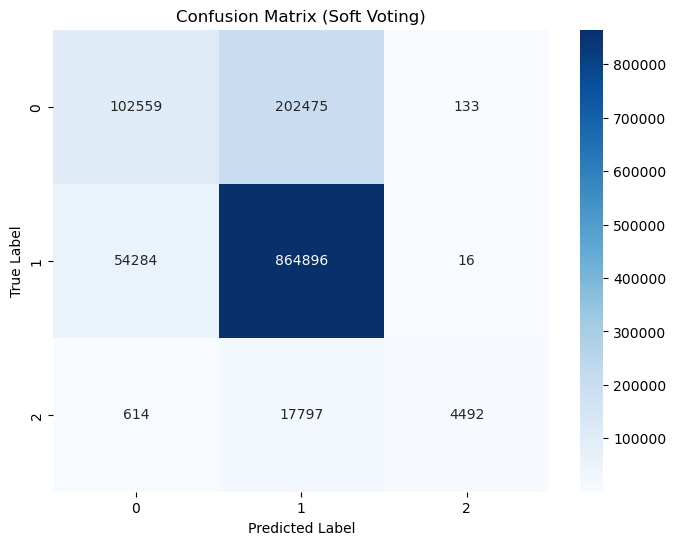


Confusion Matrix:
[[102559 202475    133]
 [ 54284 864896     16]
 [   614  17797   4492]]


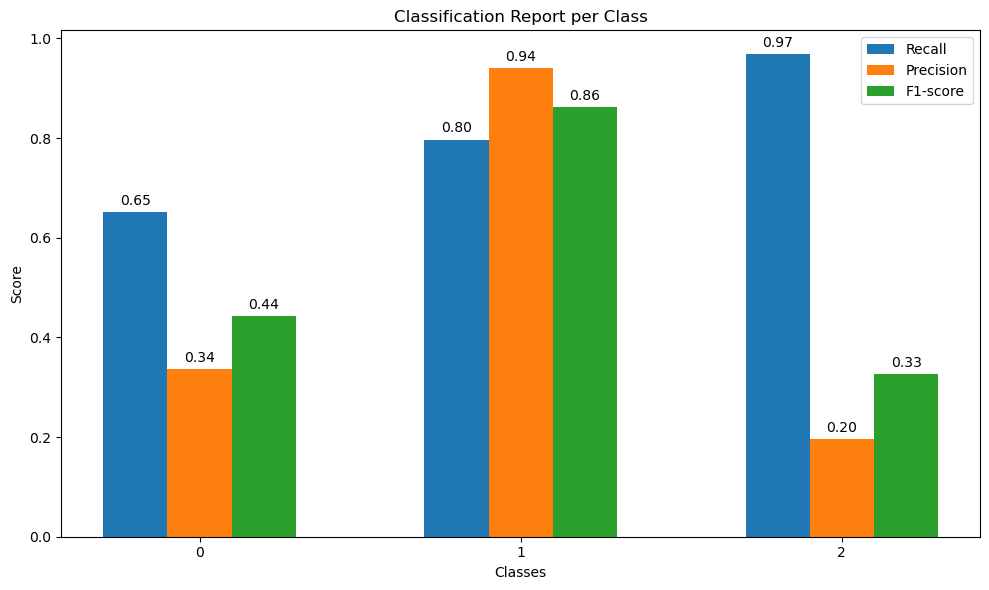

Accuracy: 0.7792620018504473
Precision: 0.8054188978833304
Recall: 0.4910443828661375


In [12]:
evaluate(x_cols)

Top 40


In [13]:
x_cols = ['Min_PacketSpeed',
 'Avg source IP count',
 'Mean_DetectCount',
 'Max_DetectCount',
 'Std_DetectCount',
 'Std_DataSpeed',
 'Attack ID',
 'Mean_DataSpeed',
 'AvgPacketLen_Mean',
 'total_seconds',
 'AvgPacketLen_Std',
 'Source IP count',
 'Max_PacketSpeed',
 'Mean_PacketSpeed',
 'Sin_DayOfYear',
 'DayOfYear',
 'PCA_4',
 'Cos_DayOfYear',
 'AvgPacketLen_Per_TotalSeconds',
 'Min_DataSpeed',
 'PCA_3',
 'Start Hour',
 'Max_DataSpeed',
 'PCA_5',
 'VictimIP_Count',
 'dist_centroid_silhouette_54',
 'PCA_2',
 'Sin_Hour',
 'Victim IP',
 'dist_centroid_silhouette_72',
 'weekday_number',
 'Cos_Hour',
 'dist_centroid_silhouette_39',
 'Detect count',
 'time_of_day',
 'dist_centroid_silhouette_98',
 'Port number',
 'dist_centroid_silhouette_15',
 'PortFrequency',
 'PortNumber_Count']


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.37      0.47    305167
           1       0.80      0.93      0.86    919196
           2       0.96      0.20      0.33     22903

    accuracy                           0.78   1247266
   macro avg       0.80      0.50      0.55   1247266
weighted avg       0.76      0.78      0.75   1247266



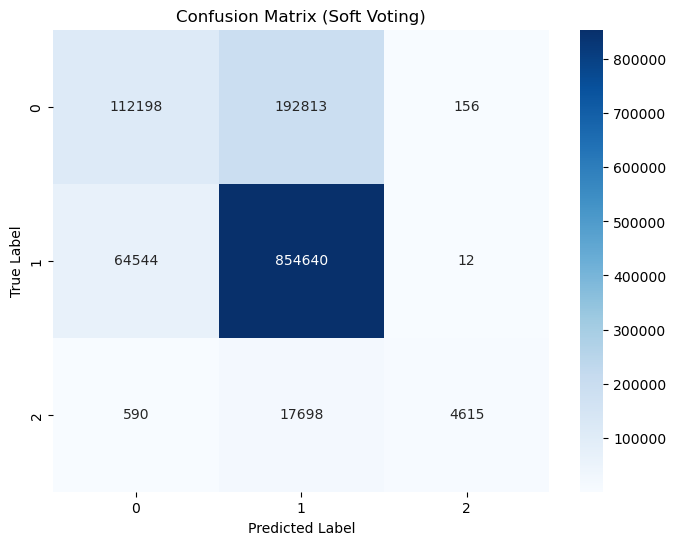


Confusion Matrix:
[[112198 192813    156]
 [ 64544 854640     12]
 [   590  17698   4615]]


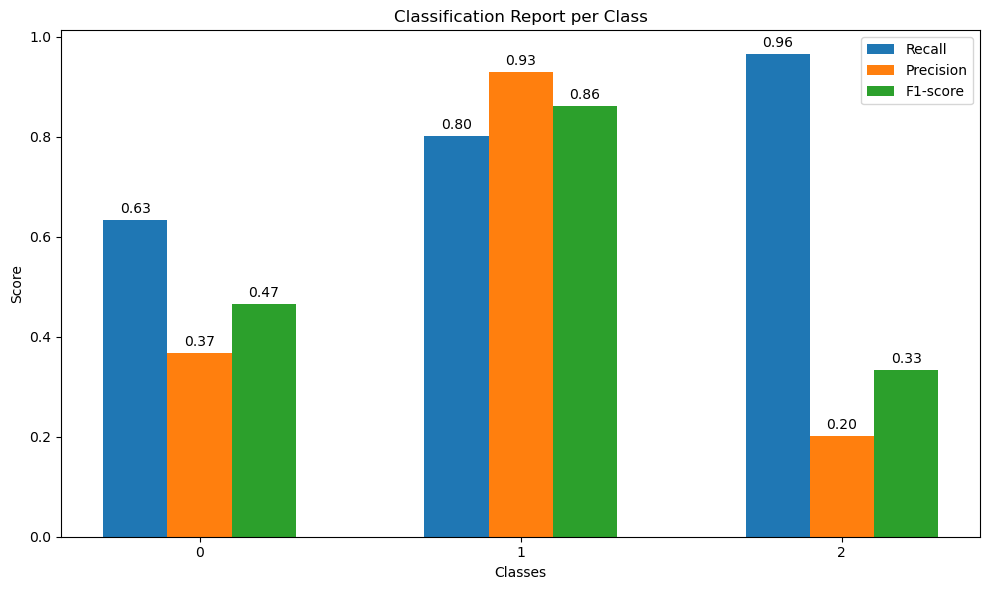

Accuracy: 0.7788659355742881
Precision: 0.799980319209381
Recall: 0.49964401043694134


In [14]:
evaluate(x_cols)

Top 20


In [15]:
x_cols = ['Min_PacketSpeed',
 'Avg source IP count',
 'Std_DetectCount',
 'Max_DetectCount',
 'Std_DataSpeed',
 'Mean_DetectCount',
 'total_seconds',
 'Attack ID',
 'AvgPacketLen_Mean',
 'Source IP count',
 'Mean_PacketSpeed',
 'AvgPacketLen_Std',
 'Mean_DataSpeed',
 'Max_PacketSpeed',
 'PCA_4',
 'Sin_DayOfYear',
 'DayOfYear',
 'Cos_DayOfYear',
 'PCA_3',
 'AvgPacketLen_Per_TotalSeconds']


Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.51      0.58    305167
           1       0.84      0.93      0.88    919196
           2       0.96      0.20      0.34     22903

    accuracy                           0.81   1247266
   macro avg       0.82      0.55      0.60   1247266
weighted avg       0.80      0.81      0.80   1247266



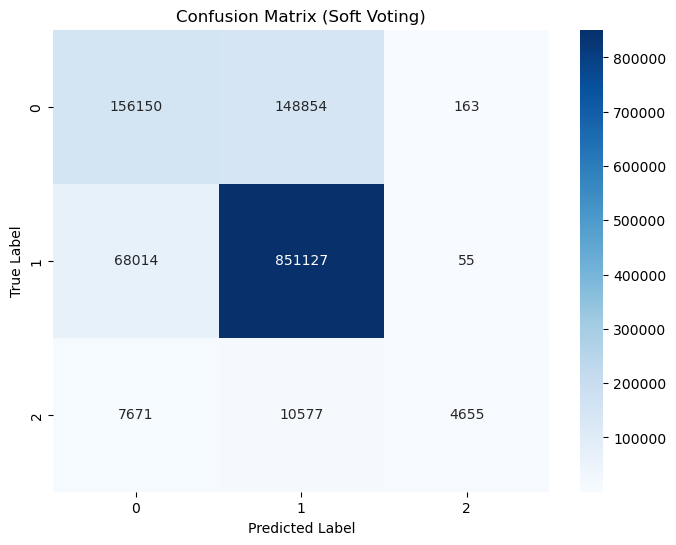


Confusion Matrix:
[[156150 148854    163]
 [ 68014 851127     55]
 [  7671  10577   4655]]


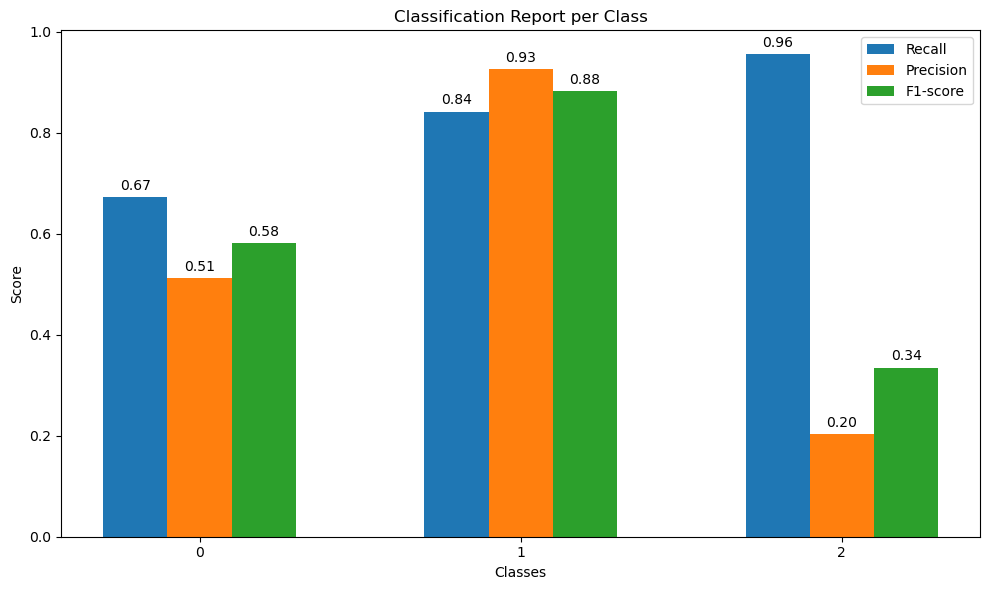

Accuracy: 0.8113201193650753
Precision: 0.8236792515945798
Recall: 0.5469609223562654


In [16]:
evaluate(x_cols)